Test `create_gaussian_template` function

Diffraction limit parameters: Airy radius = 62.46 px, Gaussian width σ = 26.23 px


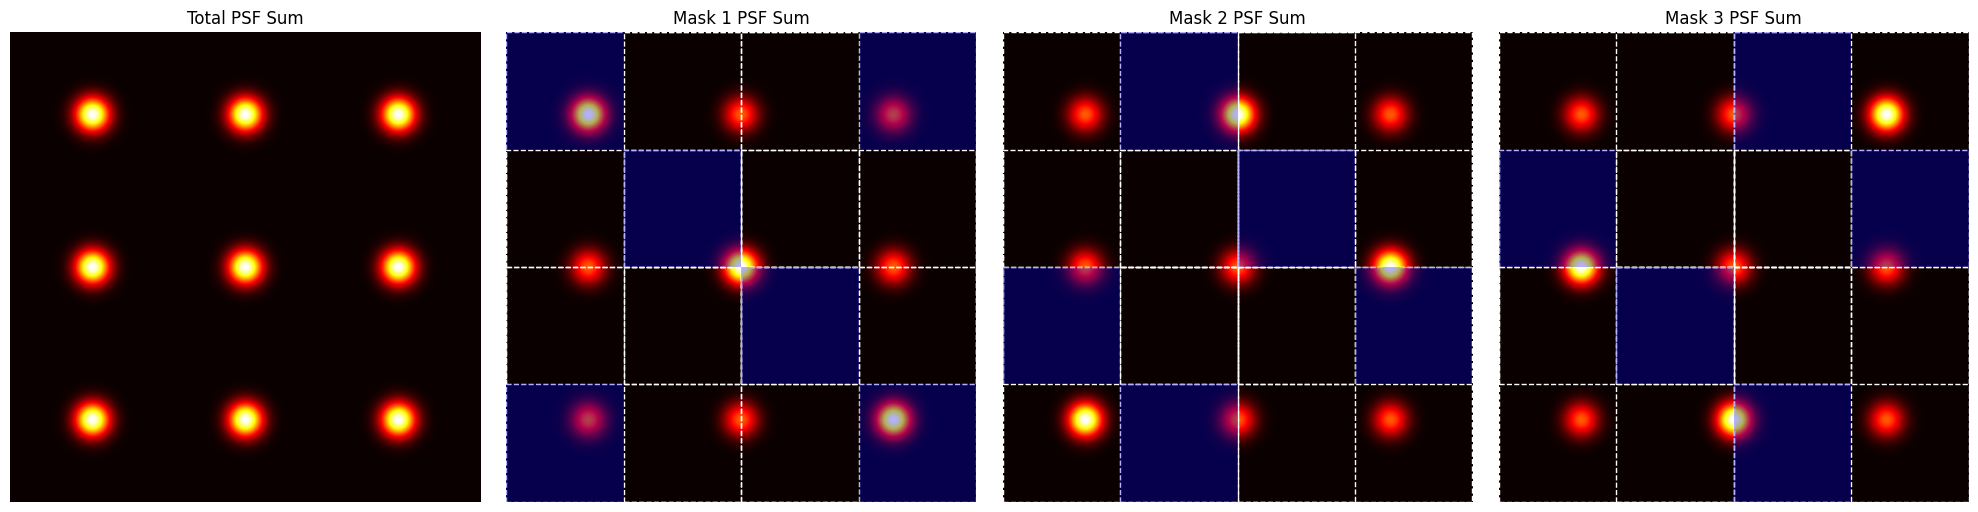

In [13]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
import numpy as np
from optics_utils import create_gaussian_template

# Test parameters
N = 1024
L = 1e-3  # 1 mm
focal_length = 0.05  # 50 mm
wavelength = 5e-7  # 500 nm
M = 3
overlap_ratio = 0.5
size_factor = 1.0
device = torch.device('cpu')
center_blend = 0.1  # Use overlapping centers
correction_factor = 1.0
num_masks = 3

# Call the function
normalized_gaussian, centers, sigma_px, mask_psfs, masks_tiles = create_gaussian_template(
    N, L, focal_length, wavelength, M, overlap_ratio, size_factor, device,
    center_blend, correction_factor, num_masks
)

# Visualization
fig, axs = plt.subplots(1, num_masks + 1, figsize=(5 * (num_masks + 1), 5))

# First, plot the total PSF
axs[0].imshow(normalized_gaussian.cpu().numpy(), cmap='hot', origin='lower')
axs[0].set_title('Total PSF Sum')
axs[0].axis('off')

# Compute lens boundaries in pixel coordinates
region_size_px = (1.0 / (M - (M - 1) * overlap_ratio)) * (N - 1)
stride_px = region_size_px * (1 - overlap_ratio)

# For each mask
for mask_id in range(num_masks):
    ax = axs[mask_id + 1]
    
    # Plot PSF sum with colormap
    psf_np = mask_psfs[mask_id].cpu().numpy()
    im = ax.imshow(psf_np, cmap='hot', origin='lower', norm=Normalize(vmin=0, vmax=np.max(psf_np)))
    ax.set_title(f'Mask {mask_id + 1} PSF Sum')
    
    # Draw dashed lines for each overlapping lens
    for i in range(M):
        for j in range(M):
            lens_x_start = i * stride_px
            lens_y_start = j * stride_px
            rect = patches.Rectangle((lens_x_start, lens_y_start), region_size_px, region_size_px,
                                     linewidth=1, edgecolor='white', facecolor='none', linestyle='--')
            ax.add_patch(rect)
    
    # Semi-transparent fill for mask tiles
    for tile in masks_tiles[mask_id]:  # Assuming masks_tiles from function, but need to extract it
        # Note: masks_tiles is local in function, so for real code, return it or compute similarly
        x_start_px = tile['x_start_norm'] * (N - 1)
        y_start_px = tile['y_start_norm'] * (N - 1)
        width_px = (tile['x_end_norm'] - tile['x_start_norm']) * (N - 1)
        height_px = (tile['y_end_norm'] - tile['y_start_norm']) * (N - 1)
        rect = patches.Rectangle((x_start_px, y_start_px), width_px, height_px,
                                 linewidth=0, facecolor='blue', alpha=0.3)
        ax.add_patch(rect)
    
    ax.axis('off')

plt.tight_layout()
plt.show()

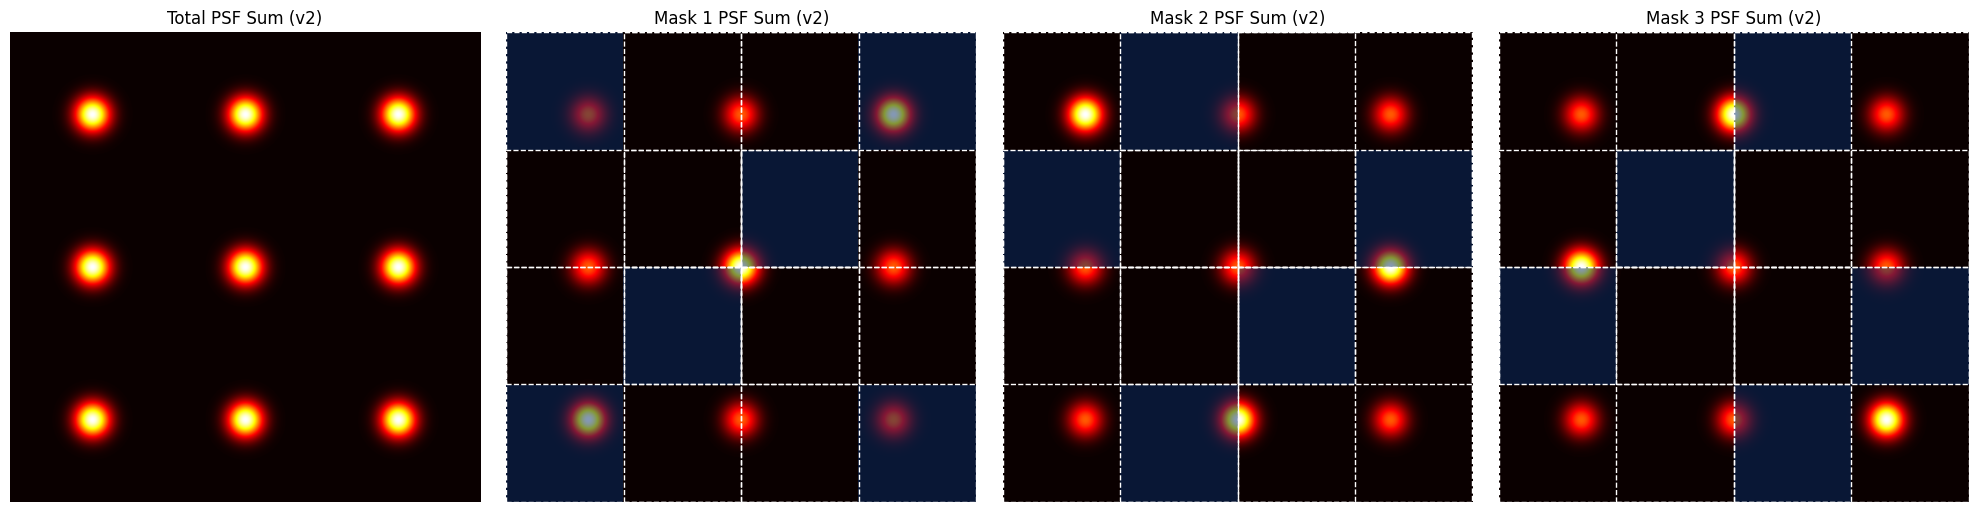

In [12]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
import numpy as np
from optics_utils import create_gaussian_template_v2

# Test parameters
N = 1024
L = 1e-3  # 1 mm
focal_length = 0.05  # 50 mm
wavelength = 5e-7  # 500 nm
M = 3
overlap_ratio = 0.5
size_factor = 1.0
device = torch.device('cpu')
center_blend = 0.1  # Use overlapping centers
airy_correction = 1.0
mask_count = 3
weighting = 'per_lens'

# Call the function
result = create_gaussian_template_v2(
    N, L, focal_length, wavelength, M, overlap_ratio, size_factor, device,
    center_blend=center_blend, airy_correction=airy_correction, mask_count=mask_count, weighting=weighting
)

normalized_gaussian = result['normalized_gaussian']
centers_pixel = result['centers_pixel']
sigma_px = result['sigma_px']
masks = result['masks']
normalized_gaussians_per_mask = result['normalized_gaussians_per_mask']
info = result['info']

# Recompute for visualization: lens boundaries
scale = N - 1
region_size_norm = info['region_size_norm']
stride_norm = info['stride_norm']
w_px = info['w_px']
s_px = info['s_px']

i_idx = torch.arange(M, device=device, dtype=torch.float32)
j_idx = torch.arange(M, device=device, dtype=torch.float32)
cx_ov_norm = i_idx * stride_norm + region_size_norm / 2.0
cy_ov_norm = j_idx * stride_norm + region_size_norm / 2.0
CX_ov, CY_ov = torch.meshgrid(cx_ov_norm, cy_ov_norm, indexing='ij')
centers_geom_pixel = torch.stack([(CX_ov * scale).reshape(-1), (CY_ov * scale).reshape(-1)], dim=-1)

# Visualization
num_masks = mask_count
fig, axs = plt.subplots(1, num_masks + 1, figsize=(5 * (num_masks + 1), 5))

# Plot total PSF
axs[0].imshow(normalized_gaussian.cpu().numpy(), cmap='hot', origin='lower')
axs[0].set_title('Total PSF Sum (v2)')
axs[0].axis('off')

# For each mask
for mask_id in range(num_masks):
    ax = axs[mask_id + 1]
    
    # Plot PSF sum with colormap
    psf_np = normalized_gaussians_per_mask[mask_id].cpu().numpy()
    vmax = psf_np.max() if psf_np.max() > 0 else 1
    im = ax.imshow(psf_np, cmap='hot', origin='lower', norm=Normalize(vmin=0, vmax=np.max(psf_np)))
    ax.set_title(f'Mask {mask_id + 1} PSF Sum (v2)')
    
    # Draw dashed lines for each overlapping lens
    for l in range(M * M):
        cx, cy = centers_geom_pixel[l]
        lens_x_start = cx - w_px / 2
        lens_y_start = cy - w_px / 2
        rect = patches.Rectangle((lens_x_start.item(), lens_y_start.item()), w_px, w_px,
                                 linewidth=1, edgecolor='white', facecolor='none', linestyle='--')
        ax.add_patch(rect)
    
    # Semi-transparent overlay for mask
    mask_np = masks[mask_id].cpu().numpy().astype(float)
    ax.imshow(mask_np, cmap='Blues', alpha=mask_np * 0.5, origin='lower', interpolation='none')
    
    ax.axis('off')

plt.tight_layout()
plt.show()